In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques pour la présentation ministérielle
plt.style.use('ggplot')
colors = {'Pessimiste': '#e74c3c', 'Normal': '#3498db', 'Optimiste': '#2ecc71'}

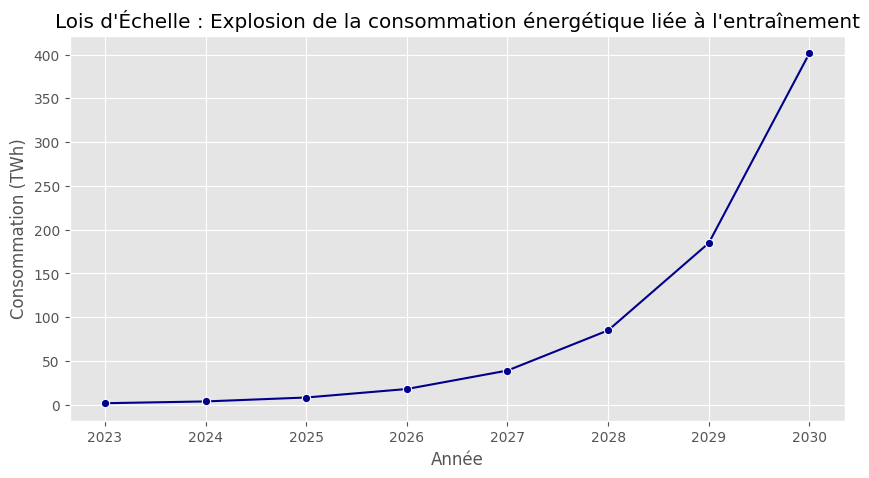

In [2]:
# Hypothèse : Croissance des modèles de 2023 à 2030
years = np.array([2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030])

# Croissance du nombre de paramètres (en milliards) - Tendance exponentielle
params_billions = 175 * (2.5 ** (years - 2023))

# Efficacité énergétique des puces (FLOPS/Watt) - Amélioration de 15% par an
efficiency_gain = 1.15 ** (years - 2023)

# Calcul de l'énergie d'entraînement relative (en TWh/an au niveau mondial)
energy_train_twh = (params_billions / 100) / efficiency_gain

df_scaling = pd.DataFrame({'Année': years, 'Paramètres_Mrd': params_billions, 'Conso_TWh': energy_train_twh})

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_scaling, x='Année', y='Conso_TWh', marker='o', color='darkblue')
plt.title("Lois d'Échelle : Explosion de la consommation énergétique liée à l'entraînement")
plt.ylabel("Consommation (TWh)")
plt.show()

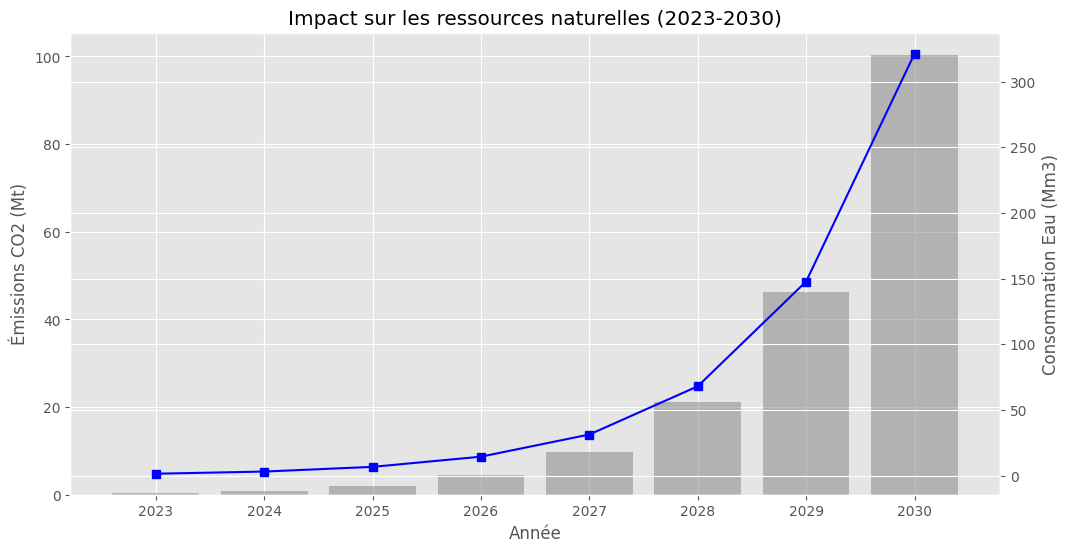

In [4]:
# Intensité carbone moyenne (gCO2/kWh) - Source IEA/Shift Project
carbon_intensity = 250

# Consommation d'eau (Litres par kWh consommé par le Data Center)
water_intensity = 0.8

df_scaling['CO2_Mt'] = (df_scaling['Conso_TWh'] * 1e9 * carbon_intensity) / 1e12 # En Millions de tonnes
df_scaling['Eau_Mm3'] = (df_scaling['Conso_TWh'] * 1e9 * water_intensity) / 1e9 # En Millions de m3

fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
ax1.bar(df_scaling['Année'], df_scaling['CO2_Mt'], color='gray', alpha=0.5, label='Émissions CO2 (Mt)')
ax2.plot(df_scaling['Année'], df_scaling['Eau_Mm3'], color='blue', marker='s', label='Conso Eau (Mm3)')

ax1.set_xlabel('Année')
ax1.set_ylabel('Émissions CO2 (Mt)')
ax2.set_ylabel('Consommation Eau (Mm3)')
plt.title("Impact sur les ressources naturelles (2023-2030)")
plt.show()

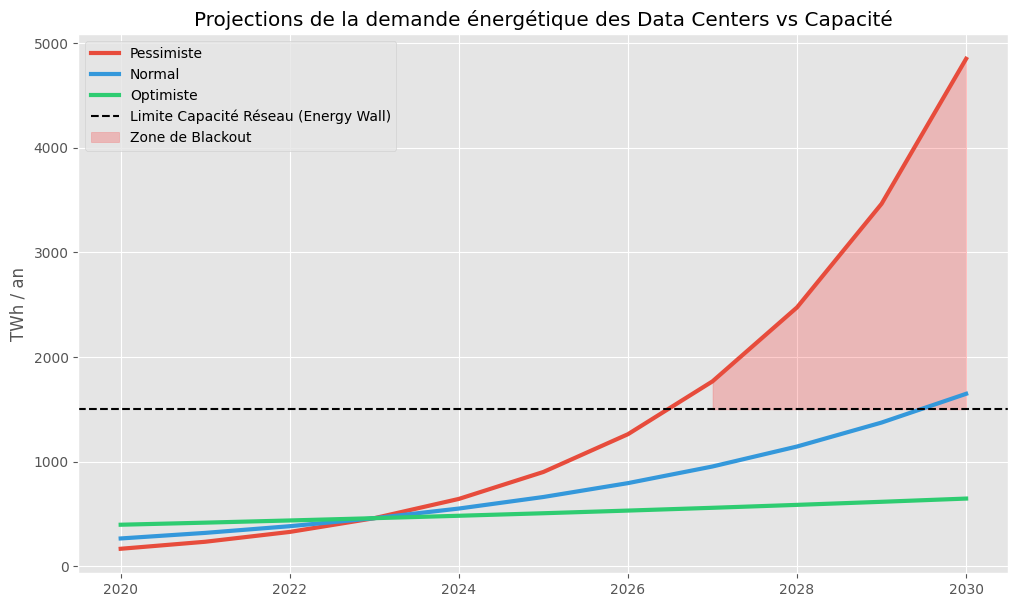

In [5]:
# Projection de la demande totale (Entraînement + Inférence)
# Pessimiste : IA générative omniprésente, peu d'optimisation
# Normal : Croissance régulée
# Optimiste : IA Frugale et percées technologiques

base_demand = 460 # TWh en 2022 (Source IEA)
scenarios = {
    'Pessimiste': base_demand * (1.4 ** (years - 2023)),
    'Normal': base_demand * (1.2 ** (years - 2023)),
    'Optimiste': base_demand * (1.05 ** (years - 2023))
}

# Capacité du réseau estimée (limite physique de production)
network_limit = np.full(len(years), 1500)

plt.figure(figsize=(12, 7))
for name, data in scenarios.items():
    plt.plot(years, data, label=name, color=colors[name], linewidth=3)

plt.axhline(y=1500, color='black', linestyle='--', label='Limite Capacité Réseau (Energy Wall)')
plt.fill_between(years, scenarios['Pessimiste'], 1500, where=(scenarios['Pessimiste'] >= 1500),
                 color='red', alpha=0.2, label='Zone de Blackout')

plt.title("Projections de la demande énergétique des Data Centers vs Capacité")
plt.ylabel("TWh / an")
plt.legend()
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration du style pour des graphiques "Présentation Board"
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

# --- RECONSTITUTION DU DATASET (Basé sur tes fichiers uploads) ---
# Données extraites de : "Consommation de Ressources et Émissions de GES des Modèles d'IA.xlsx"
# et du papier "Estimating the carbon footprint of BLOOM"

data = {
    'Modele': ['ResNet50 (Vison)', 'BERT-Large (NLP)', 'GPT-3 (175B)', 'BLOOM (176B)', 'Gopher (280B)', 'GPT-4 (Est.)'],
    'Annee': [2015, 2018, 2020, 2022, 2021, 2023],
    'Parametres_Milliards': [0.025, 0.34, 175, 176, 280, 1800],
    'Energie_Training_MWh': [0.5, 1.5, 1287, 433, 1100, 25000], # Est. pour GPT-4
    'CO2_Training_Tonnes': [0.2, 0.7, 502, 25, 410, 12000], # BLOOM est bas grâce au nucléaire français (Jean Zay)
    'Source_Energie': ['Mixte', 'Mixte', 'Charbon/Gaz (US)', 'Nucléaire (FR)', 'Mixte', 'Mixte']
}

df = pd.DataFrame(data)

# Calcul d'efficacité (Paramètres par tonne de CO2) pour montrer l'impact du mix énergétique
df['Efficacite_Ecologique'] = df['Parametres_Milliards'] / df['CO2_Training_Tonnes']

display(df)

,Modele,Annee,Parametres_Milliards,Energie_Training_MWh,CO2_Training_Tonnes,Source_Energie,Efficacite_Ecologique
0,ResNet50 (Vison),2015,0.025,0.5,0.2,Mixte,0.125000
1,BERT-Large (NLP),2018,0.340,1.5,0.7,Mixte,0.485714
2,GPT-3 (175B),2020,175.000,1287.0,502.0,Charbon/Gaz (US),0.348606
3,BLOOM (176B),2022,176.000,433.0,25.0,Nucléaire (FR),7.040000
4,Gopher (280B),2021,280.000,1100.0,410.0,Mixte,0.682927
5,GPT-4 (Est.),2023,1800.000,25000.0,12000.0,Mixte,0.150000


/tmp/ipython-input-141671409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x='Modele', y='CO2_Training_Tonnes', palette=colors)


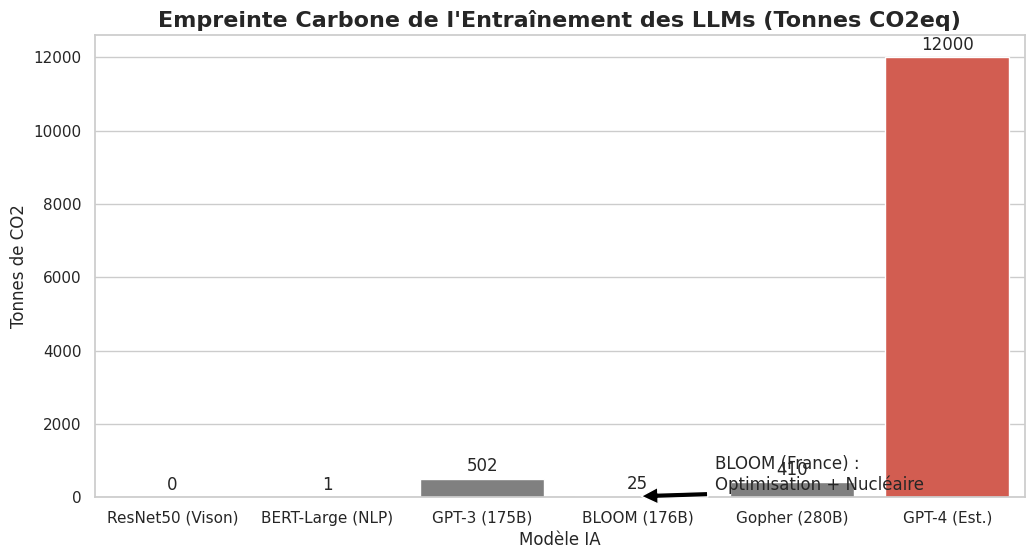

In [7]:
# Création d'une palette de couleurs : Rouge pour pollueurs, Vert pour modèles optimisés/FR
colors = ['grey' if x != 'Nucléaire (FR)' else '#2ecc71' for x in df['Source_Energie']]
colors[-1] = '#e74c3c' # GPT-4 en rouge (estimation haute)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=df, x='Modele', y='CO2_Training_Tonnes', palette=colors)

# Ajout des étiquettes de valeur
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Empreinte Carbone de l\'Entraînement des LLMs (Tonnes CO2eq)', fontsize=16, fontweight='bold')
plt.ylabel('Tonnes de CO2')
plt.xlabel('Modèle IA')
plt.annotate('BLOOM (France) : \nOptimisation + Nucléaire', xy=(3, 25), xytext=(3.5, 200),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

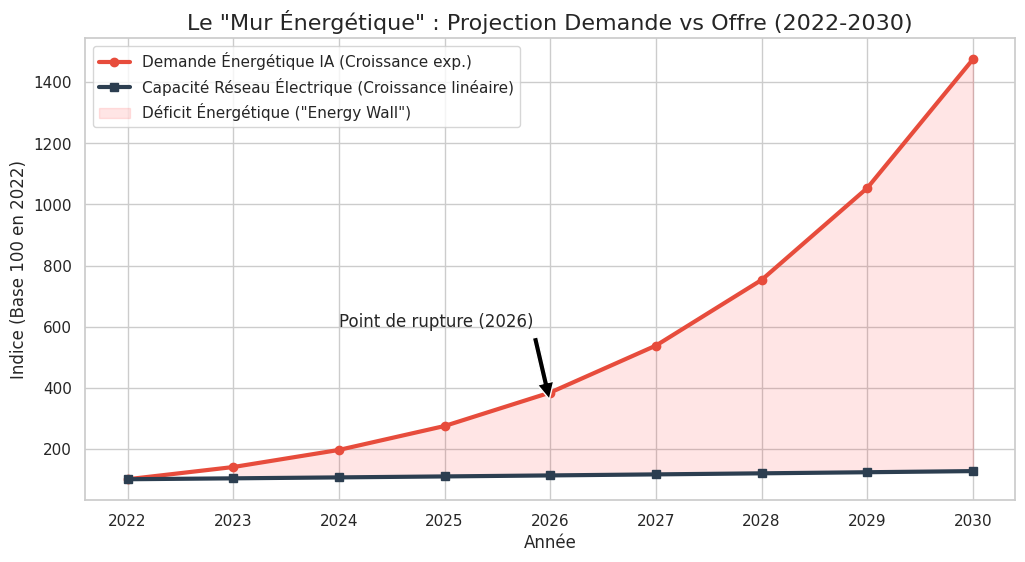

In [8]:
# Projection temporelle (2022-2030)
years = np.arange(2022, 2031)
# Scénario "Business as Usual" : Demande double tous les 2 ans (Loi de Moore accélérée par l'IA)
demand_index = 100 * (1.4 ** (years - 2022))
# Capacité de production électrique (Augmentation lente +3% par an)
supply_index = 100 * (1.03 ** (years - 2022))

plt.figure(figsize=(12, 6))

plt.plot(years, demand_index, marker='o', linewidth=3, color='#e74c3c', label='Demande Énergétique IA (Croissance exp.)')
plt.plot(years, supply_index, marker='s', linewidth=3, color='#2c3e50', label='Capacité Réseau Électrique (Croissance linéaire)')

# Zone de déficit (Le Mur)
plt.fill_between(years, demand_index, supply_index, where=(demand_index > supply_index),
                 color='red', alpha=0.1, label='Déficit Énergétique ("Energy Wall")')

plt.title('Le "Mur Énergétique" : Projection Demande vs Offre (2022-2030)', fontsize=16)
plt.ylabel('Indice (Base 100 en 2022)')
plt.xlabel('Année')
plt.legend()
plt.annotate('Point de rupture (2026)', xy=(2026, 350), xytext=(2024, 600),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.show()